# SPX ±1% Move Prediction with XGBoost
This notebook trains a gradient boosting model (XGBoost) to predict whether the S&P 500 (proxied by SPY) will move **at least ±1 %** on the next trading day.

Adjust paths and feature lists as needed for your own dataset.

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [16]:
# --- Update the path to your merged dataset ---
DATA_PATH = "./data/processed/1_merged_stock_sentiment.csv"

data = pd.read_csv(DATA_PATH, parse_dates=['date'])
data.head()


,date,spy_Close,spy_High,spy_Low,spy_Open,spy_Volume,qqq_Close,qqq_High,qqq_Low,qqq_Open,...,spx_Low,spx_Open,spx_Volume,es_Close,es_High,es_Low,es_Open,es_Volume,avg_headline_sentiment,avg_article_sentiment
0,2014-06-02,159.182388,159.256666,158.414952,159.223651,64656000,83.556450,83.757968,83.025175,83.739645,...,1915.979980,1923.869995,2509020000,1921.75,1924.25,1913.75,1921.25,1053526,-0.533892,-0.575179
1,2014-06-03,159.099869,159.182382,158.646003,158.794534,65047000,83.519829,83.657228,83.171756,83.281670,...,1918.790039,1923.069946,2867180000,1922.00,1923.50,1916.00,1921.50,948001,-0.511021,-0.618714
2,2014-06-04,159.421646,159.512419,158.662458,158.827496,55529000,83.831261,83.968660,83.180910,83.309148,...,1918.599976,1923.060059,2793920000,1925.75,1927.00,1916.00,1922.75,917108,-0.563256,-0.580557
3,2014-06-05,160.461456,160.626495,159.017344,159.603247,92103000,84.536583,84.692299,83.620594,83.904549,...,1922.930054,1928.520020,3113270000,1938.50,1940.75,1921.00,1925.50,1676659,-0.549064,-0.616599
4,2014-06-06,161.228867,161.270117,160.733738,160.808003,78696000,85.022064,85.022064,84.683146,84.848024,...,1942.410034,1942.410034,2864300000,1949.25,1949.75,1937.75,1938.50,1205739,-0.457761,-0.572454


In [17]:
# ========================
# Updated feature engineering
# ========================

# --- SPX-based Return and Volatility Features ---
data['spx_return_1d'] = data['spx_Close'].pct_change(1)
data['spx_return_3d'] = data['spx_Close'].pct_change(3)
data['spx_return_5d'] = data['spx_Close'].pct_change(5)
data['spx_return_10d'] = data['spx_Close'].pct_change(10)

data['spx_volatility_3d'] = data['spx_Close'].rolling(3).std()
data['spx_volatility_5d'] = data['spx_Close'].rolling(5).std()
data['spx_volatility_10d'] = data['spx_Close'].rolling(10).std()

# --- SPX True Range and ATR Features ---
data['true_range_spx'] = (data['spx_High'] - data['spx_Low'])
data['avg_true_range_5d_spx'] = data['true_range_spx'].rolling(5).mean()

# --- Sentiment Features ---
# data['avg_sentiment'] = (data['avg_headline_sentiment'] + data['avg_article_sentiment']) / 2
# data['sentiment_lag1'] = data['avg_sentiment'].shift(1)
# data['sentiment_delta'] = data['avg_sentiment'] - data['sentiment_lag1']

# --- Gap % for SPX ---
data['gap_pct_spx'] = (data['spx_Open'] - data['spx_Close'].shift(1)) / data['spx_Close'].shift(1)

# --- Volume Z-Score for SPX ---
data['vol_z_spx'] = (data['spx_Volume'] / data['spx_Volume'].rolling(20).mean()) - 1

# --- Sentiment Divergence (vs SPX move) ---
# data['sent_div_spx'] = data['avg_sentiment'] - data['spx_return_1d']

# --- Target Creation ---
data['spx_return_t+1'] = data['spx_Close'].pct_change(1).shift(-1)
data['target'] = (data['spx_return_t+1'].abs() >= 0.0075).astype(int)

# --- Final cleanup ---
data = data.dropna().reset_index(drop=True)
cols_to_drop = [col for col in data.columns if col.startswith(('qqq_', 'es_', 'spy_'))]
data = data.drop(cols_to_drop, axis=1)
print(data.head())
# data[['date', 'spx_return_t+1', 'target']].head()




        date    spx_Close     spx_High      spx_Low     spx_Open  spx_Volume  \
0 2014-06-27  1960.959961  1961.469971  1952.180054  1956.560059  4290590000   
1 2014-06-30  1960.229980  1964.239990  1958.219971  1960.790039  3037350000   
2 2014-07-01  1973.319946  1978.579956  1962.290039  1962.290039  3188240000   
3 2014-07-02  1974.619995  1976.670044  1972.579956  1973.060059  2851480000   
4 2014-07-03  1985.439941  1985.589966  1975.880005  1975.880005  1998090000   

   avg_headline_sentiment  avg_article_sentiment  spx_return_1d  \
0               -0.533053              -0.561263       0.001911   
1               -0.535458              -0.604152      -0.000372   
2               -0.453113              -0.450136       0.006678   
3               -0.570595              -0.627245       0.000659   
4               -0.549292              -0.600278       0.005480   

   spx_return_3d  ...  spx_return_10d  spx_volatility_3d  spx_volatility_5d  \
0       0.005631  ...        0.012809

In [18]:
# --- Feature columns: exclude date, target, and return_t+1 from the inputs
feature_cols = [col for col in data.columns if col not in ['date', 'spx_return_t+1', 'target']]

# --- Prepare features and target
X = data[feature_cols]
y = data['target']

print("Feature count:", len(feature_cols))

Feature count: 18


In [19]:
# Use the last 20%% of observations for testing to respect temporal order
split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


In [20]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [21]:
model = xgb.XGBClassifier(
    booster='dart',
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

eval_set = [(X_train_scaled, y_train), (X_test_scaled, y_test)]
model.fit(X_train_scaled, y_train,
          eval_set=eval_set,
          verbose=100)


[0]	validation_0-auc:0.82016	validation_1-auc:0.54163
[100]	validation_0-auc:0.96331	validation_1-auc:0.65455
[200]	validation_0-auc:0.98893	validation_1-auc:0.65153
[300]	validation_0-auc:0.99822	validation_1-auc:0.64451
[400]	validation_0-auc:0.99975	validation_1-auc:0.64263
[500]	validation_0-auc:0.99998	validation_1-auc:0.63937
[600]	validation_0-auc:1.00000	validation_1-auc:0.63477
[700]	validation_0-auc:1.00000	validation_1-auc:0.63427
[799]	validation_0-auc:1.00000	validation_1-auc:0.63373


XGBClassifier(base_score=None, booster='dart', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=800,
              n_jobs=-1, num_parallel_tree=None, ...)

Accuracy: 0.6502835538752363

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.79      0.75       349
           1       0.48      0.37      0.42       180

    accuracy                           0.65       529
   macro avg       0.60      0.58      0.58       529
weighted avg       0.63      0.65      0.64       529

Confusion Matrix:
 [[277  72]
 [113  67]]
Test ROC‑AUC: 0.6337312957656798


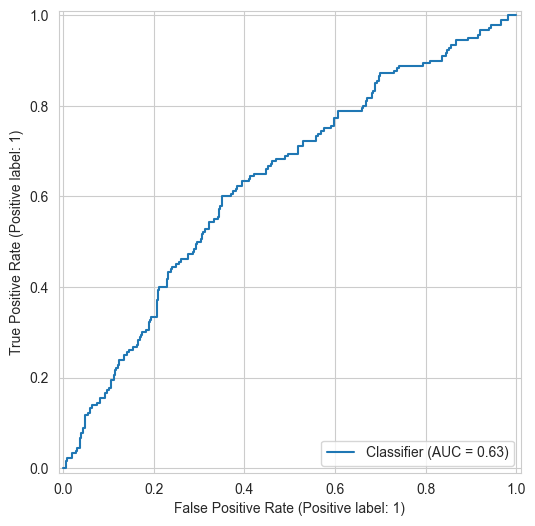

In [22]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC‑AUC
auc = roc_auc_score(y_test, y_prob)
print("Test ROC‑AUC:", auc)

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()


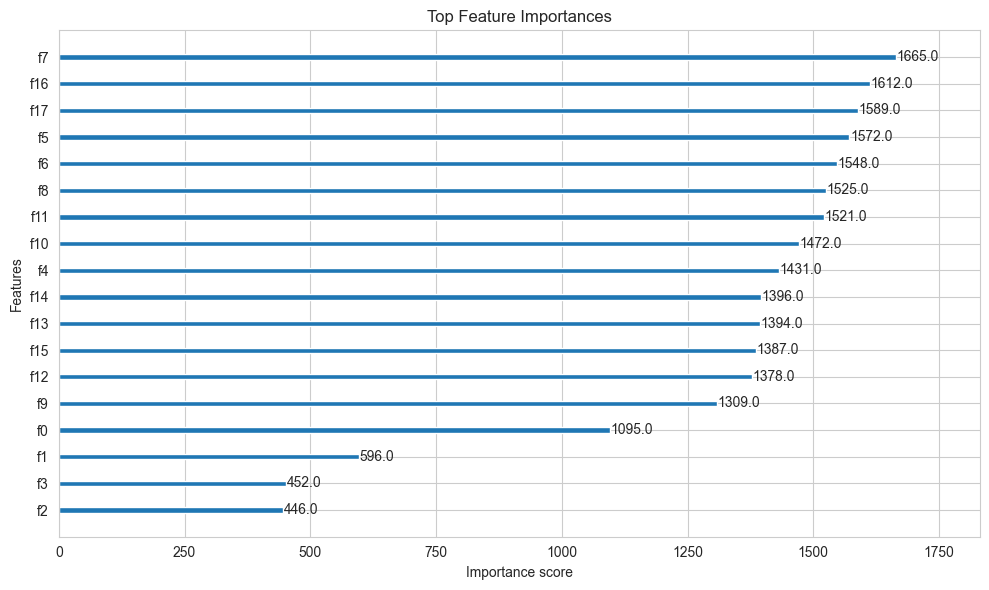

In [23]:
xgb.plot_importance(model, max_num_features=20)
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()


In [24]:
import joblib
joblib.dump(model, "spx_xgb_model.pkl")
joblib.dump(scaler, "spx_feature_scaler.pkl")
print("Artifacts saved: spx_xgb_model.pkl, spx_feature_scaler.pkl")


Artifacts saved: spx_xgb_model.pkl, spx_feature_scaler.pkl


In [25]:
def predict_next_day_movement(latest_row: pd.Series) -> float:
    """Return probability of ±1 % move for the next day."""
    X_latest = scaler.transform(latest_row[feature_cols].values.reshape(1, -1))
    return float(model.predict_proba(X_latest)[0, 1])

latest_row = data.iloc[-1]
prob = predict_next_day_movement(latest_row)
print(f"Probability of SPX moving ±1% tomorrow (based on last available day {latest_row['date'].date()}): {prob:.1%}")


Probability of SPX moving ±1% tomorrow (based on last available day 2024-12-27): 49.4%


/Users/nickyjosephson/Desktop/Personal/ML-Stock-Prediction/stock-forecast-env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [26]:
from sklearn.metrics import precision_recall_curve

probs = model.predict_proba(X_test)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test, probs)

for t, p, r in zip(thresholds, prec[:-1], rec[:-1]):
    print(f"Threshold: {t:.2f} | Precision: {p:.2f} | Recall: {r:.2f}")

Threshold: 0.21 | Precision: 0.34 | Recall: 1.00
Threshold: 0.22 | Precision: 0.34 | Recall: 0.99
Threshold: 0.22 | Precision: 0.34 | Recall: 0.98
Threshold: 0.22 | Precision: 0.34 | Recall: 0.98
Threshold: 0.24 | Precision: 0.34 | Recall: 0.97
Threshold: 0.26 | Precision: 0.33 | Recall: 0.97
Threshold: 0.26 | Precision: 0.33 | Recall: 0.96
Threshold: 0.27 | Precision: 0.33 | Recall: 0.96
Threshold: 0.27 | Precision: 0.33 | Recall: 0.92
Threshold: 0.27 | Precision: 0.33 | Recall: 0.92
Threshold: 0.27 | Precision: 0.33 | Recall: 0.92
Threshold: 0.27 | Precision: 0.33 | Recall: 0.91
Threshold: 0.28 | Precision: 0.33 | Recall: 0.91
Threshold: 0.28 | Precision: 0.33 | Recall: 0.90
Threshold: 0.28 | Precision: 0.33 | Recall: 0.89
Threshold: 0.29 | Precision: 0.25 | Recall: 0.02
Threshold: 0.29 | Precision: 0.27 | Recall: 0.02
Threshold: 0.29 | Precision: 0.30 | Recall: 0.02
Threshold: 0.31 | Precision: 0.33 | Recall: 0.02
Threshold: 0.31 | Precision: 0.29 | Recall: 0.01
Threshold: 0.32 | Pr

In [27]:
from sklearn.metrics import f1_score

best_f1 = 0
best_threshold = 0

for t in np.arange(0.2, 0.8, 0.01):
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best F1: {best_f1:.4f} at threshold = {best_threshold:.2f}")

Best F1: 0.5078 at threshold = 0.20


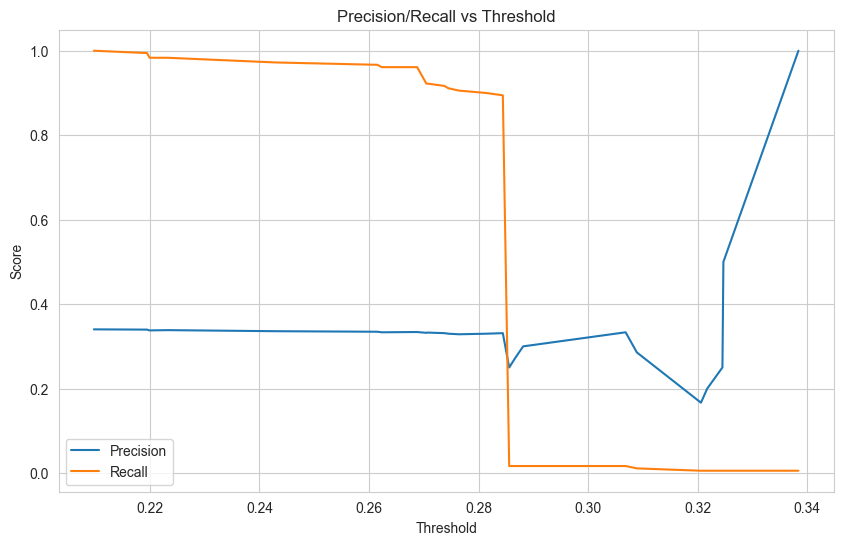

In [28]:
import matplotlib.pyplot as plt

plt.plot(thresholds, prec[:-1], label='Precision')
plt.plot(thresholds, rec[:-1], label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision/Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
import joblib
joblib.dump(model, 'xgb_model.pkl')

['xgb_model.pkl']